# Selecting an interval to overfit

## imports

In [1]:
import os
import yaml
import pandas as pd
import numpy as np
import pyranges as pr

import seaborn as sns
import matplotlib.pyplot as plt

from figutils import (
    cm,
    set_figure_style, 
)

set_figure_style()

## data

In [2]:
# paths

ROOT = ".."
RAW_DIR = os.path.join(ROOT,"data","raw")

with open(os.path.join(ROOT,"config","config.yaml"), "r") as stream:
    config = yaml.safe_load(stream)

FOLDS_DIR = config["finetuning"]["alphagenome"]["folds_dir"]
FOLD = config["preprocessing"]["overfitting"]["fold"]
train_intervals_file = os.path.join(ROOT, FOLDS_DIR, FOLD, "train.bed")

SAMPLES = config["preprocessing"]["overfitting"]["samples"]
star_junctions_files = {
    s: os.path.join(ROOT, config["rnaseq"]["sf3b1mut"]["path"], "STAR", s, "paper_pass.SJ.out.tab")
    for s in SAMPLES
}

In [3]:
# loads

intervals = pd.read_table(
    train_intervals_file, header=None, names=["chrom", "start", "end"],
)

junctions = pd.concat([
    pd.read_table(
        f,
        header=None,
        names=["chrom", "intron_start", "intron_end", "strand", "motif",
                "annotated", "n_unique", "n_multi", "max_overhang"],
    ).assign(sample=s)
    .query("n_unique>0") # drop junctions that are not supported by unique reads
    for s, f in star_junctions_files.items()
])

## prep

In [4]:
# junction exonic coordinates
junctions["j_start"] = junctions["intron_start"] - 1
junctions["j_end"]   = junctions["intron_end"]
    
# junctions in intervals
gr_intervals = pr.PyRanges(
    intervals.rename(columns={"chrom": "Chromosome", "start": "Start", "end": "End"})
)
gr_junctions = pr.PyRanges(pd.DataFrame({
    "Chromosome": junctions["chrom"].values,
    "Start":      junctions["j_start"].values,
    "End":        junctions["j_end"].values,
    "n_unique":   junctions["n_unique"].values,
    "strand":   junctions["strand"].values,
    "sample": junctions["sample"].values,
}))

joined_df = gr_intervals.join(gr_junctions, how=None).df
contained = joined_df[
    (joined_df["Start_b"] >= joined_df["Start"]) &
    (joined_df["End_b"]   <= joined_df["End"])
]
contained

,Chromosome,Start,End,Start_b,End_b,n_unique,strand,sample
0,chr1,116683483,117732059,116754951,116760401,1,1,SRR17111303
1,chr1,116683483,117732059,116764606,116768463,2,1,SRR17111303
2,chr1,116683483,117732059,116775640,116775960,1,2,SRR17111311
3,chr1,116683483,117732059,116776499,116782494,2,2,SRR17111311
4,chr1,116683483,117732059,116782601,116805604,4,2,SRR17111311
...,...,...,...,...,...,...,...,...
9234093,chrX,3896614,4945190,3903569,3905112,1,2,SRR17111303
9234094,chrX,3896614,4945190,3906232,3920193,2,2,SRR17111303
9234095,chrX,3896614,4945190,3906232,3920193,1,2,SRR17111311
9234096,chrX,3896614,4945190,3906232,3919593,1,2,SRR17111303


## number of splice junctions per interval

In [5]:
agg = (
    contained
    .groupby(["Chromosome","Start","End","sample"])
    .agg(
        total_reads=("n_unique", "sum"), 
        avg_reads=("n_unique", "mean"), 
        n_junctions=("n_unique", "count"),
    )
    .reset_index()
    .rename(columns={"Chromosome": "chrom", "Start": "start", "End": "end"})
)

scored = pd.concat([
    intervals
    .merge(agg.query("sample==@s"), on=["chrom", "start", "end"], how="left")
    .fillna(0)
    .sort_values(["sample","total_reads", "n_junctions"], ascending=False)
    .reset_index(drop=True)
    .assign(
        sample = s,
        total_reads_p1 = lambda d: d["total_reads"]+1,
        avg_reads_p1 = lambda d: d["avg_reads"]+1,
        n_junctions_p1 = lambda d: d["n_junctions"]+1,
    )
    for s in SAMPLES
])

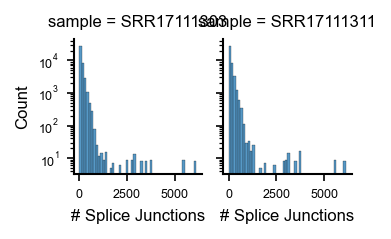

In [6]:
X = scored.copy()

g = sns.displot(
    kind="hist",
    data=X,
    x="n_junctions_p1",
    col="sample",
    bins=50,
    height=4*cm, aspect=0.8
)

g.set(yscale="log", xlabel="# Splice Junctions", ylabel="Count")

plt.show()

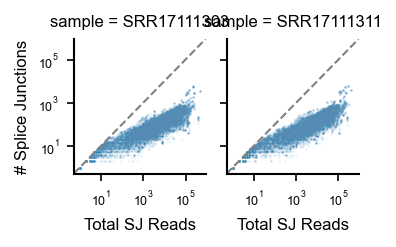

In [7]:
X = scored.copy()

g = sns.relplot(
    kind="scatter",
    data=X,
    x="total_reads_p1",
    y="n_junctions_p1",
    col="sample",
    s=1, alpha=0.1,
    height=4*cm, aspect=0.8
)

g.set(xscale="log", yscale="log", xlabel="Total SJ Reads", ylabel="# Splice Junctions")

for ax in g.axes.flat:
    lims = [
        min(ax.get_xlim()[0], ax.get_ylim()[0]),
        max(ax.get_xlim()[1], ax.get_ylim()[1]),
    ]

    ax.plot(lims, lims, "--", color="grey", linewidth=1)
    ax.set_xlim(lims)
    ax.set_ylim(lims)

plt.show()

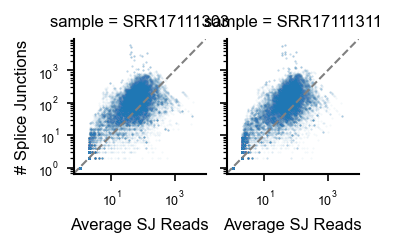

In [8]:
X = scored.copy()

g = sns.relplot(
    kind="scatter",
    data=X,
    x="avg_reads_p1",
    y="n_junctions_p1",
    col="sample",
    s=1, alpha=0.05,
    height=4*cm, aspect=0.8
)

g.set(xscale="log", yscale="log", xlabel="Average SJ Reads", ylabel="# Splice Junctions")

for ax in g.axes.flat:
    lims = [
        min(ax.get_xlim()[0], ax.get_ylim()[0]),
        max(ax.get_xlim()[1], ax.get_ylim()[1]),
    ]

    ax.plot(lims, lims, "--", color="grey", linewidth=1)
    ax.set_xlim(lims)
    ax.set_ylim(lims)

plt.show()

## select intervals: as many junctions and as many reads as possible

In [21]:
sele = (
    scored
    .groupby(["chrom","start","end"])
    .agg(
        total_reads=("total_reads", "mean"), 
        avg_reads=("avg_reads", "mean"), 
        n_junctions=("n_junctions", "mean"),
    )
    .query("n_junctions > 10 & avg_reads > 1") # at least one junction on average
    .sort_values("avg_reads", ascending=False)
    .reset_index()
)

sele

,chrom,start,end,total_reads,avg_reads,n_junctions
0,chr6,73513481,74562057,317929.0,3182.197089,99.5
1,chr5,170677316,171725892,120848.0,3180.210526,38.0
2,chr5,170431451,171480027,120848.0,3180.210526,38.0
3,chr5,170480624,171529200,120848.0,3180.210526,38.0
4,chr5,170529797,171578373,120848.0,3180.210526,38.0
...,...,...,...,...,...,...
30921,chr13,108863877,109912453,14.0,1.175000,10.5
30922,chr12,78011906,79060482,14.0,1.175000,10.5
30923,chr13,108913050,109961626,14.0,1.175000,10.5
30924,chr13,109404780,110453356,13.5,1.156250,11.0


In [22]:
# high
sele.iloc[int(0.05 * (len(sele) - 1))]

chrom               chr15
start            43925021
end              44973597
total_reads       64001.5
avg_reads      229.965784
n_junctions         276.0
Name: 1546, dtype: object

In [11]:
junctions.query("chrom=='chr15' & j_start > 43925021 & j_end < 44973597")

,chrom,intron_start,intron_end,strand,motif,annotated,n_unique,n_multi,max_overhang,sample,j_start,j_end
209654,chr15,44288905,44289158,1,1,1,1,0,1,SRR17111303,44288904,44289158
209655,chr15,44289357,44307237,1,1,1,1,0,15,SRR17111303,44289356,44307237
209656,chr15,44289357,44322964,1,1,1,118,4,55,SRR17111303,44289356,44322964
209658,chr15,44305693,44307233,1,1,0,2,0,25,SRR17111303,44305692,44307233
209659,chr15,44308849,44322964,1,1,0,1,0,24,SRR17111303,44308848,44322964
...,...,...,...,...,...,...,...,...,...,...,...,...
230056,chr15,44862312,44881511,2,2,0,1,0,27,SRR17111311,44862311,44881511
230057,chr15,44878197,44881494,2,2,0,1,0,53,SRR17111311,44878196,44881494
230058,chr15,44881606,44881764,2,2,0,1,0,36,SRR17111311,44881605,44881764
230059,chr15,44881606,44882317,2,2,0,64,2,62,SRR17111311,44881605,44882317


In [23]:
# medium
sele.iloc[int(0.5 * (len(sele) - 1))]

chrom               chr6
start           89090380
end             90138956
total_reads      15509.5
avg_reads      54.275171
n_junctions        286.0
Name: 15462, dtype: object

In [15]:
junctions.query("chrom=='chr6' & j_start > 89090380 & j_end < 90138956")[["j_start","j_end","strand","n_unique"]].drop_duplicates().sort_values("n_unique")

,j_start,j_end,strand,n_unique
103249,89105260,89105426,2,1
103250,89131982,89143746,2,1
103251,89132478,89143746,2,1
103252,89143833,89145633,2,1
103285,89269234,89271627,2,1
...,...,...,...,...
103291,89329957,89333085,2,1058
113851,89338543,89342323,2,1061
103301,89338543,89342323,2,1071
103300,89338310,89338458,2,1164


In [24]:
# low
sele.iloc[int(0.95 * (len(sele) - 1))]

chrom               chr4
start          167644849
end            168693425
total_reads        553.0
avg_reads        6.78744
n_junctions         79.5
Name: 29378, dtype: object

In [16]:
junctions.query("chrom=='chr4' & j_start > 167644849 & j_end < 168693425")[["j_start","j_end","strand","n_unique"]].drop_duplicates().sort_values("n_unique")

,j_start,j_end,strand,n_unique
79276,168288315,168291747,2,1
79300,168400978,168403981,2,1
79314,168457432,168457891,2,1
79305,168415799,168416681,2,1
79288,168371763,168373665,2,1
...,...,...,...,...
87187,168221881,168224242,2,21
87222,168306720,168308005,2,23
87188,168224385,168225528,2,26
87189,168225676,168236251,2,28
